# homr

homr is an Optical Music Recognition (OMR) software designed to transform camera pictures of sheet music into machine-readable [MusicXML](https://www.w3.org/2021/06/musicxml40/) format. The resulting MusicXML files can be further processed using tools such as [musescore](https://musescore.com/).

[![Open in GitHub](https://img.shields.io/badge/Open%20in-GitHub-blue?logo=github)](https://github.com/liebharc/homr)


In [1]:
%%capture
#@title Setup
!pip install poetry
!git clone https://github.com/liebharc/homr.git
%cd homr
!poetry config virtualenvs.create false --local
!poetry install --only main,gpu

In [2]:
%%capture
#@title Install MuseScore
!add-apt-repository --yes ppa:mscore-ubuntu/mscore3-stable
!apt-get update
!apt-get --yes install musescore3

Saving Screenshot 2026-04-20 at 8.14.40 PM.png to Screenshot 2026-04-20 at 8.14.40 PM.png


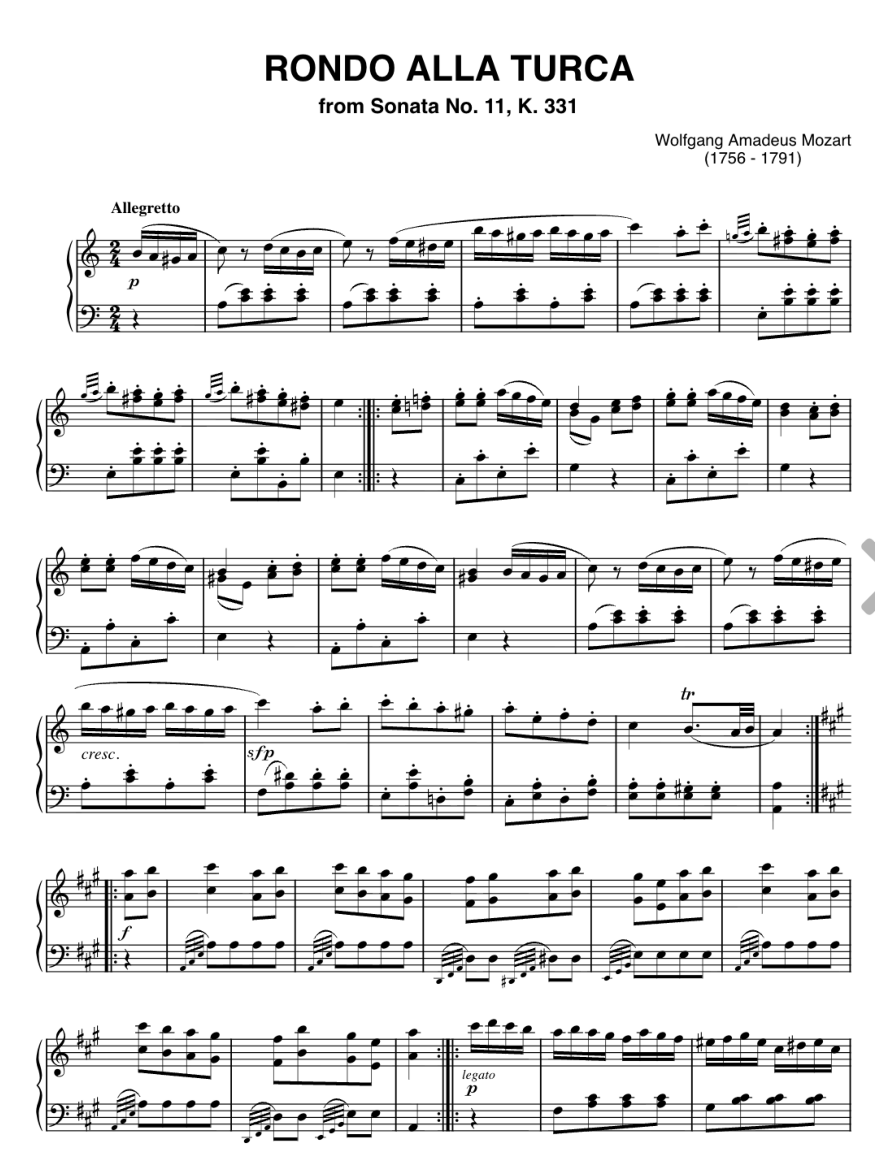

In [5]:
#@title Upload files and run recognition
from google.colab import files
from matplotlib import pyplot as plt

filenames = files.upload().keys()

for file_name in filenames:
    img = plt.imread(file_name)
    plt.rcParams['figure.figsize'] = (15, 15)
    plt.axis('off')
    plt.imshow(img)
    plt.show()

In [7]:
for file_name in filenames:
    !poetry run homr "{file_name}"

Skipping virtualenv creation, as specified in config file.
/usr/local/lib/python3.12/dist-packages/musicxml/xmlelement/xmlelement.py:413: SyntaxWarning: invalid escape sequence '\@'
  ``Possible attributes``: ``color``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeColor`, ``default_x``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeTenths`, ``default_y``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeTenths`, ``font_family``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeFontFamily`, ``font_size``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeFontSize`, ``font_style``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeFontStyle`, ``font_weight``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeFontWeight`, ``placement``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeAboveBelow`, ``relative_x``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeTenths`, ``relative_y``\@ :obj:`~musicxml.xsd.xsdsimpletype.XSDSimpleTypeTenths`
/usr/local/lib/python3.12/dist-packages/musicxml/xmle

env: DEBIAN_FRONTEND=noninteractive
env: QT_QPA_PLATFORM=offscreen
QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
convert <Screenshot 2026-04-20 at 8.14.40 PM.musicxml>...
	to <Screenshot 2026-04-20 at 8.14.40 PM.mp3>
Attempting to load LAME from system search paths
Loading LAME from libmp3lame.so.0
LAME library successfully loaded
Loading soundfont: /usr/share/mscore3-3.2/sound/sf3/MuseScore_General.sf3
MIDI collision detected: newly played...
 - Note; Pitch: C#5 (sounding as C#5); Duration: Eighth (on 500‰ off 1000‰); Voice: 2; Measure: 29; Beat: 1; Staff: 1
 ... interferes with already playing...
 - Note; Pitch: C#5 (sounding as C#5); Duration: Eighth (on 500‰ off 1000‰); Voice: 1; Measure: 29; Beat: 1; Staff: 1
 ... which will continue to sound.
MIDI collision detected: newly played...
 - Note; Pitch: C#5 (sounding as C#5); Duration: Eighth (on 500‰ off 1000‰); Voice: 2; Measure: 29; Beat: 1; Staff: 1
 ... interferes with already playing...
 - Note; Pitc

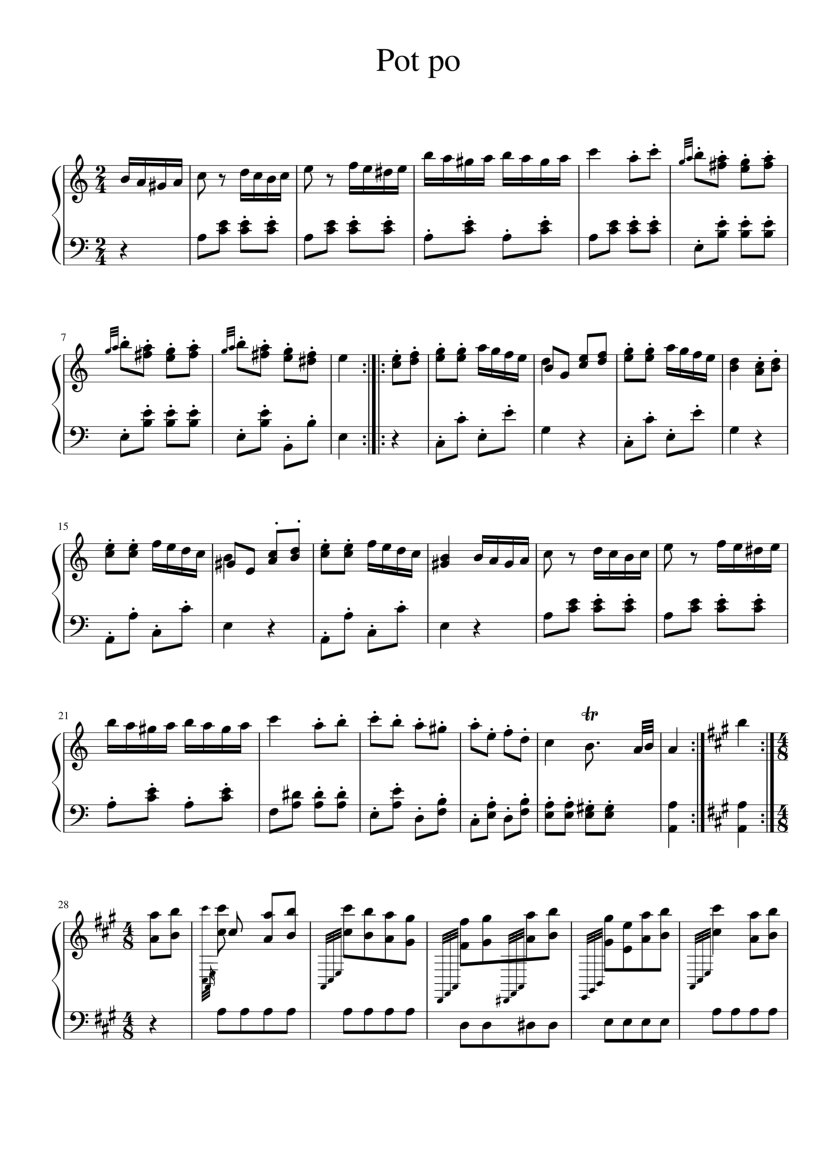

In [8]:
#@title Render MusicXML

# Copied from oemer's Colab Notebook
from matplotlib import pyplot as plt
import IPython.display as dsp


%env DEBIAN_FRONTEND=noninteractive
%env QT_QPA_PLATFORM=offscreen


def remove_extension(file: str):
    return file[:file.rindex('.')]


for file_name in filenames:
    file_name = remove_extension(file_name)
    !musescore3 -o "{file_name}.mp3" "{file_name}.musicxml"
    !musescore3 -o "{file_name}.png" "{file_name}.musicxml"
    img = plt.imread(f"{file_name}-1.png")
    plt.rcParams['figure.figsize'] = (15, 15)
    plt.axis('off')
    plt.imshow(img)
    plt.show()

    dsp.display(dsp.Audio(f"{file_name}.mp3"))